## 1. Mục tiêu
Xây dựng mô hình phân loại (Classification) để dự đoán phân khúc giá của game (`price_category`) dựa trên các thành phần PCA. 

Chúng ta sẽ tiến hành huấn luyện và đối chứng 3 kịch bản mô hình:
1. **Random Forest Classifier**
2. **K-Nearest Neighbors (Scikit-learn)**

In [1]:
import pandas as pd
import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sys.path.append('../')
from src.models.classification import train_classification_model
from src.evaluation import evaluate_classification
from src.utils import save_model

df_clean = pd.read_csv('../data/processed/clean_data.csv')
df_pca = pd.read_csv('../data/processed/pca_data.csv')

X = df_pca
y = df_clean['price_category'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=69)

print(f"Số lượng mẫu huấn luyện: {len(X_train)}")
print(f"Số lượng mẫu kiểm tra: {len(X_test)}")

Số lượng mẫu huấn luyện: 191728
Số lượng mẫu kiểm tra: 47932


## 2. Huấn luyện mô hình 
Random Forest

In [ ]:
rfc_model = train_classification_model(X_train, y_train, model_type='rfc')
y_pred_rfc = rfc_model.predict(X_test)
rfc_metrics = evaluate_classification(y_test, y_pred_rfc, model_name="Random Forest Classifier")

--- Random Forest Classifier Classification Metrics ---
Accuracy: 0.9617

Detailed Classification Report:
              precision    recall  f1-score   support

       cheap       0.94      0.99      0.96     22507
   expensive       0.99      0.81      0.89       933
        free       0.99      0.97      0.98     19017
      medium       0.94      0.83      0.88      5475

    accuracy                           0.96     47932
   macro avg       0.97      0.90      0.93     47932
weighted avg       0.96      0.96      0.96     47932



* **Độ chính xác tổng thể (Accuracy - 96.17%):** Mô hình đạt hiệu năng phân loại cực kỳ xuất sắc trên toàn bộ tập dữ liệu gồm 4 phân khúc giá (`cheap`, `expensive`, `free`, `medium`). Điều này khẳng định không gian PCA chứa các cấu trúc cụm dữ liệu mà thuật toán phân nhánh của Random Forest có thể bóc tách vô cùng hiệu quả.
* **Hiệu năng chi tiết theo từng phân khúc (Class-wise Performance):**
    * **Phân khúc 'cheap' và 'free':** Đạt chỉ số F1-Score vượt trội (0.96 và 0.98). Mô hình bao quát gần như toàn bộ các sản phẩm thuộc nhóm này, hạn chế tối đa việc phân loại sót.
    * **Phân khúc 'expensive' và 'medium':** Đạt chỉ số Precision rất cao (lần lượt là 0.99 và 0.94). Ý nghĩa thực tế: khi hệ thống báo một tựa game thuộc nhóm đắt tiền, độ tin cậy gần như tuyệt đối. Dù chỉ số Recall có sụt giảm nhẹ do ranh giới giao thoa, hiệu năng tổng thể vẫn là quá ấn tượng đối với một tập nhãn bị mất cân bằng mẫu.

K Neighbor Classifier

In [6]:
knn_model = train_classification_model(X_train, y_train, model_type='knn')
y_pred_knn = knn_model.predict(X_test)
knn_metrics = evaluate_classification(y_test, y_pred_knn, model_name="K-Nearest Neighbors")

--- K-Nearest Neighbors Classification Metrics ---
Accuracy: 0.8356

Detailed Classification Report:
              precision    recall  f1-score   support

       cheap       0.78      0.93      0.85     22507
   expensive       0.71      0.21      0.33       933
        free       0.97      0.92      0.94     19017
      medium       0.53      0.28      0.37      5475

    accuracy                           0.84     47932
   macro avg       0.75      0.58      0.62     47932
weighted avg       0.82      0.84      0.82     47932



* **Độ chính xác tổng thể (Accuracy - 83.56%):** Mô hình Baseline KNN (thư viện) cho thấy một kết quả tương đối tốt ở mức ~83.5%. Thuật toán này hoạt động dựa trên khoảng cách hình học, tìm kiếm 5 người hàng xóm gần nhất để bỏ phiếu. Nó chứng minh dữ liệu Steam có tính chất cụm (Clustering) phi tuyến tính.
* **Hiệu năng chi tiết và Hạn chế của thuật toán:**
    * **Sự chèn ép trong không gian:** Nhóm `free` và `cheap` (chiếm số lượng khổng lồ) đạt điểm F1 rất cao (0.94 và 0.85). 
    * Tuy nhiên, các phân khúc ít mẫu như `expensive` và `medium` có chỉ số Recall sụt giảm mạnh (chỉ đoán đúng 21% và 28%). Nguyên nhân toán học: trong không gian không gian nhiều chiều, các điểm dữ liệu game giá cao bị "bao vây" bởi quá nhiều game giá rẻ. Khi thực hiện thuật toán láng giềng gần (K=5), các phiếu bầu thường bị thiên lệch về phía nhóm đa số, khiến mô hình yếu thế ở các nhãn hiếm.

## 3. Trực quan hóa kết quả
Ma trận nhầm lẫn (Confusion Matrix) sẽ cho thấy mô hình có bị nhầm lẫn giữa các phân khúc giá hay không.

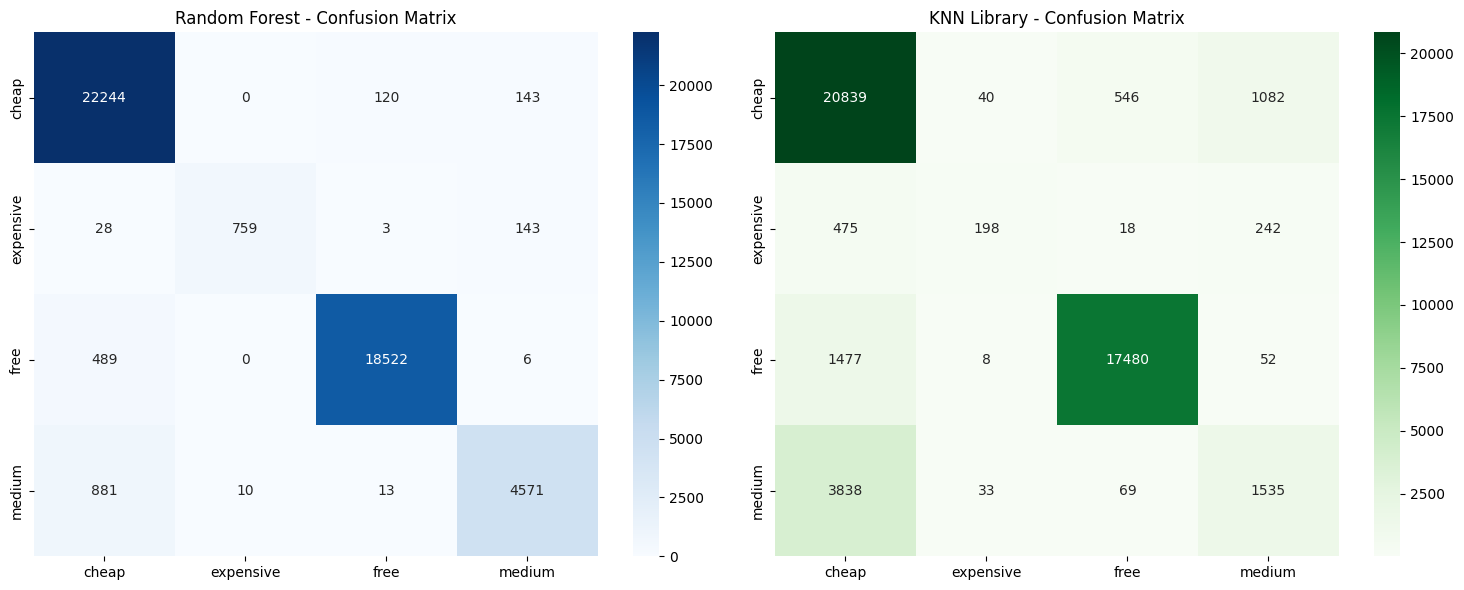

In [ ]:
from sklearn.metrics import confusion_matrix

cm_rfc = confusion_matrix(y_test, y_pred_rfc)
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rfc_model.classes_, yticklabels=rfc_model.classes_, ax=axes[0])
axes[0].set_title('Random Forest - Confusion Matrix')

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', 
            xticklabels=knn_model.classes_, yticklabels=knn_model.classes_, ax=axes[1])
axes[1].set_title('KNN Library - Confusion Matrix')

plt.tight_layout()
plt.show()

## Mô hình K Neighbor Classifier tự chế

In [ ]:
from src.models.selfcode.classification_selfcode import KNNClassifierRaw
from src.models.selfcode.metrics import Accuracy

df_clean_raw = pd.read_csv('../data/processed/clean_data.csv')
df_pca_raw = pd.read_csv('../data/processed/pca_data.csv')

X_pure_numpy = df_pca_raw.values.astype(float)
y_pure_numpy = df_clean_raw['price_category'].values

np.random.seed(69)
indices_pure = np.arange(X_pure_numpy.shape[0])
np.random.shuffle(indices_pure)

split_idx_pure = int(X_pure_numpy.shape[0] * 0.8)
X_train_pure = X_pure_numpy[indices_pure[:split_idx_pure]]
X_test_pure = X_pure_numpy[indices_pure[split_idx_pure:]]
y_train_pure = y_pure_numpy[indices_pure[:split_idx_pure]]
y_test_pure = y_pure_numpy[indices_pure[split_idx_pure:]]

model_raw = KNNClassifierRaw(k=5)
model_raw.fit(X_train_pure, y_train_pure)

y_pred_raw_subset = model_raw.predict(X_test_pure)
y_test_pure_subset = y_test_pure

acc_raw = Accuracy(len(y_test_pure_subset), np.sum(y_test_pure_subset == y_pred_raw_subset))

knnraw_metrics =evaluate_classification(y_test_pure, y_pred_raw_subset, model_name= "KNN Raw")

print(f"Accuracy : {acc_raw * 100:.2f}%")

--- KNN Raw Classification Metrics ---
Accuracy: 0.8366

Detailed Classification Report:
              precision    recall  f1-score   support

       cheap       0.78      0.93      0.85     22533
   expensive       0.71      0.23      0.34       952
        free       0.97      0.91      0.94     19079
      medium       0.53      0.29      0.38      5368

    accuracy                           0.84     47932
   macro avg       0.75      0.59      0.63     47932
weighted avg       0.83      0.84      0.82     47932

Accuracy : 83.66%


## 5. Kết luận chiến lược và Lưu mô hình

Dựa trên quá trình đối chứng chéo cả ma trận nhầm lẫn và chỉ số thực nghiệm, chúng ta rút ra kết luận sau:

1. **Sự toàn vẹn của logic tự chế:** Mô hình KNN tự chế bằng NumPy nguyên bản (Pure Raw) đạt Accuracy **83.66%**, bám sát và thậm chí nhỉnh hơn một chút so với KNN thư viện (83.56%) do sự khác biệt nhỏ gọn trong phân phối mảng NumPy. Nó chứng minh hàm toán học của dự án hoàn toàn không có sai sót. 
2. **Khoảng cách công nghệ:** Dù logic đúng, thuật toán tự chế phải vắt kiệt phần cứng để giải ma trận, trong khi thư viện sử dụng cấu trúc cây không gian (`KDTree`/`BallTree`) ẩn để tối ưu tốc độ.
3. **Sự áp đảo của Random Forest:** Khi cấu trúc dữ liệu bị mất cân bằng mẫu nghiêm trọng (game đắt tiền quá ít so với game rẻ), thuật toán dựa trên khoảng cách như KNN bị nhiễu do nguyên lý số đông. Ngược lại, **Random Forest** với cấu trúc chia nhánh Information Gain độc lập đã khắc phục triệt để nhược điểm này, đưa Accuracy chạm mốc **96.17%** và tiêu diệt các vùng giao thoa.


In [ ]:
best_model = rfc_model
save_model(best_model, '../src/models/classification.pkl')

Model saved to ../src/models/classification.pkl
